### Project: Customer Segmentation & Targeting
### Date: 28/10/2025
### Objective: To identify key customer groups to inform marketing strategies.

In [1]:
# Importing the required libraries
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["OMP_NUM_THREADS"] = "1"


In [2]:
# Loading the mall customer dataset
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Exploring data for better understanding 
print("Shape of data:", data.shape)

Shape of data: (200, 5)


In [4]:
print("\nFirst 5 rows:\n", data.head()) # Observing firt 5 entries 


First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
print("\nData summary:\n", data.describe()) # finding the descriptive statistics of dataframe 


Data summary:
        CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [6]:
print("\nMissing values:\n", data.isnull().sum()) 


Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


##### No missing values as the dataset is from Kaggle

In [7]:
# Data preprocessing converting Gender
data['Gender'] = data['Gender'].map({'Male':0, 'Female': 1})

In [8]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
x = data[features]

In [9]:
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [10]:
# Trying different cluster counts to see which one fits best
inertia, silhouette = [], []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

Text(0, 0.5, 'Inertia')

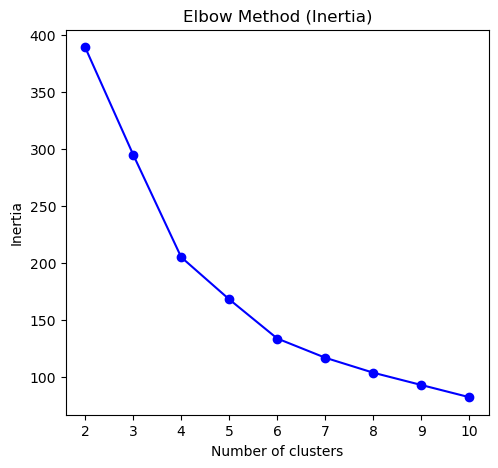

In [11]:
# Plot elbow curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(list(K), inertia, 'o-', color='blue')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

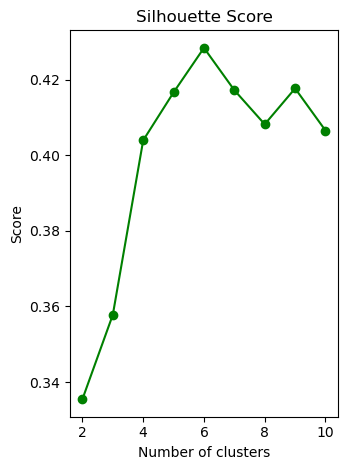

In [12]:
# Plot silhouette scores
plt.subplot(1,2,2)
plt.plot(K, silhouette, 'o-', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

##### I initially tried 4 clusters but results overlapped. Looks like k=5 gives a good balance between inertia drop and silhouette score.

In [13]:
# Apply KMeans with k
optimal_k = 5  # adjust based on elbow/silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
# Visualize clusters using PCA 
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
data['PCA1'] = components[:, 0]
data['PCA2'] = components[:, 1]

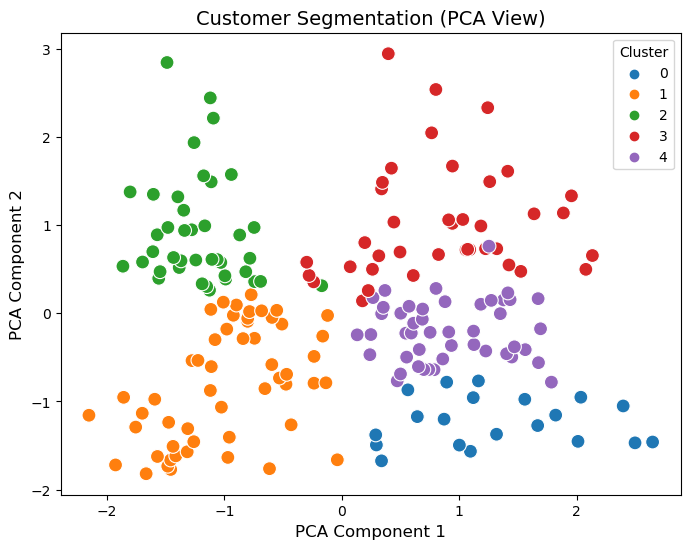

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=data, palette='tab10', s=100)
plt.title('Customer Segmentation (PCA View)', fontsize=14)
plt.xlabel('PCA Component 1', fontsize=12)
plt.ylabel('PCA Component 2', fontsize=12)
plt.legend(title='Cluster')
plt.show()

In [16]:
cluster_summary = data.groupby('Cluster')[features].mean().round(2)
print("\nCluster Summary:\n", cluster_summary)



Cluster Summary:
            Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        46.25               26.75                   18.35
1        25.19               41.09                   62.24
2        32.88               86.10                   81.53
3        39.87               86.10                   19.36
4        55.64               54.38                   48.85


In [17]:
# Analyze clusters
for cluster_id, row in cluster_summary.iterrows():
    print(f"\nCluster {cluster_id}:")
    print(f"  Avg Age: {row['Age']}")
    print(f"  Avg Income: {row['Annual Income (k$)']}")
    print(f"  Avg Spending Score: {row['Spending Score (1-100)']}")


Cluster 0:
  Avg Age: 46.25
  Avg Income: 26.75
  Avg Spending Score: 18.35

Cluster 1:
  Avg Age: 25.19
  Avg Income: 41.09
  Avg Spending Score: 62.24

Cluster 2:
  Avg Age: 32.88
  Avg Income: 86.1
  Avg Spending Score: 81.53

Cluster 3:
  Avg Age: 39.87
  Avg Income: 86.1
  Avg Spending Score: 19.36

Cluster 4:
  Avg Age: 55.64
  Avg Income: 54.38
  Avg Spending Score: 48.85


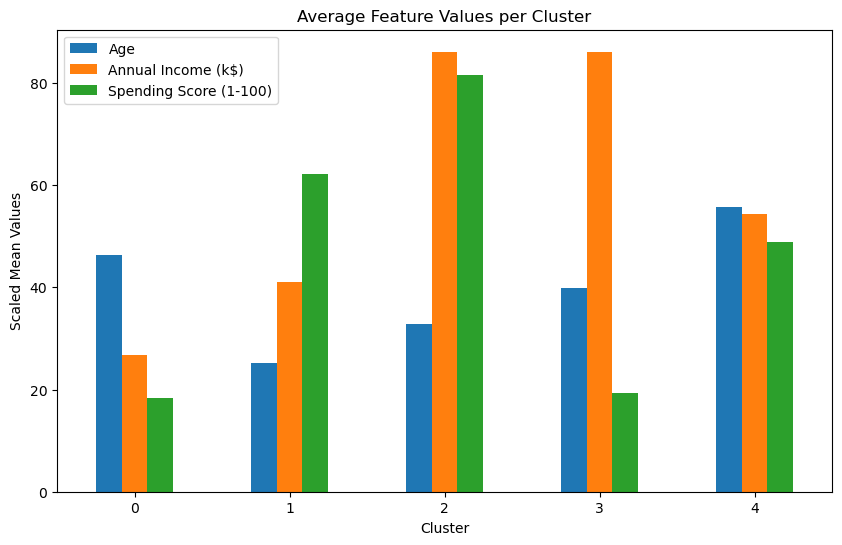

In [18]:
# Visualize cluster characteristics
cluster_summary.plot(kind='bar', figsize=(10,6))
plt.title("Average Feature Values per Cluster")
plt.ylabel("Scaled Mean Values")
plt.xticks(rotation=0)
plt.show()

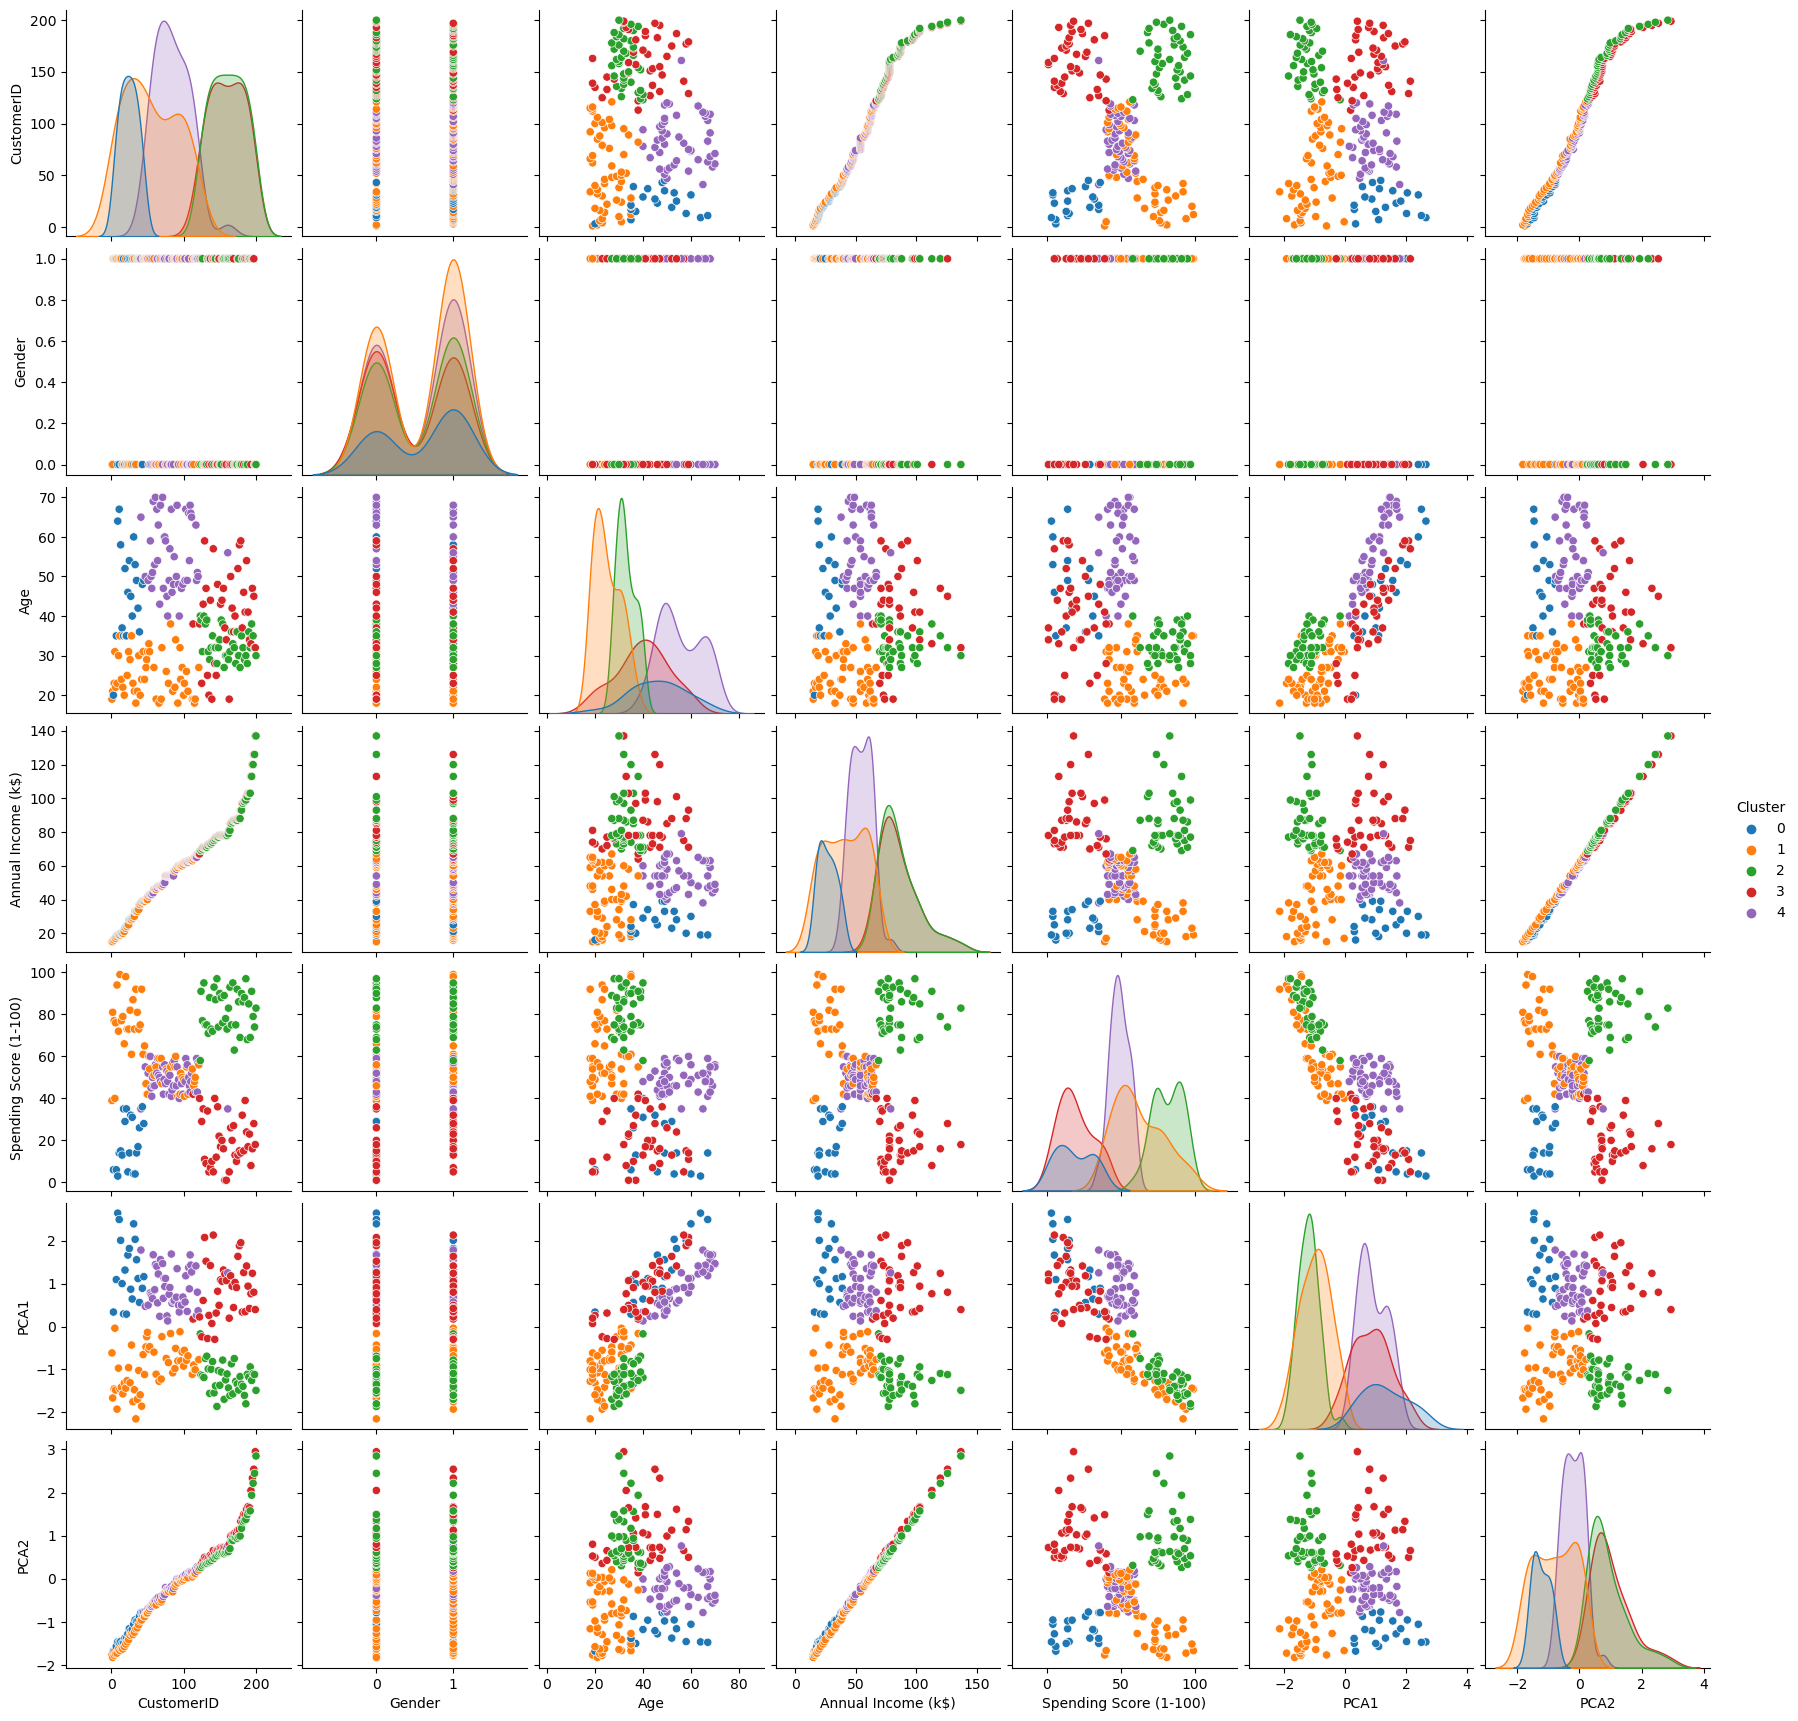

In [19]:
sns.pairplot(data, hue='Cluster', palette='tab10')
plt.show()

In [20]:
data.groupby('Cluster')[features].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [21]:
# Save clustered data in csv file 
data.to_csv("clustered_customers.csv", index=False)

### Insights Summary 

#### Cluster 0 – Older, Low Income, Low Spending
#### 1.	Represents mature customers with limited disposable income.
#### 2.	They spend cautiously and may need retention or discount-based engagement.
________________________________________
#### Cluster 1 – Young, Moderate Income, High Spending
#### 1.	Young professionals who enjoy spending despite mid-level income.
#### 2.	Great candidates for loyalty programs or targeted marketing campaigns.
________________________________________
#### Cluster 2 – Mid-Age, High Income, High Spending
#### 1.	Financially strong customers with a tendency to spend more freely.
#### 2.	Ideal for premium products, VIP experiences, or personalized offers.
________________________________________
#### Cluster 3 – Mature, High Income, Low Spending
#### 1.	Wealthy but conservative in spending behaviour.
#### 2.	Could respond to value-based messaging or product education to increase spending.
________________________________________
#### Cluster 4 – Senior, Moderate Income, Average Spending
#### 1.	Balanced group with average income and spending patterns.
#### 2.	Stable customer base — good for maintaining consistent sales.
